# Load and explore the data

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("microsoft_stock_prices_2016_2026_refined.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,2016-02-03,45.671837,46.748837,44.883786,46.626252,57559800
1,2016-02-04,45.531754,46.240999,44.980118,45.619313,46987100
2,2016-02-05,43.920628,45.531751,43.395263,45.479213,62009000
3,2016-02-08,43.263927,43.404025,42.195681,43.386512,59290500
4,2016-02-09,43.150074,43.990662,42.615951,42.922417,46740500


# Convert the Date column to datetime and set it as index

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.index

DatetimeIndex(['2016-02-03', '2016-02-04', '2016-02-05', '2016-02-08',
               '2016-02-09', '2016-02-10', '2016-02-11', '2016-02-12',
               '2016-02-16', '2016-02-17',
               ...
               '2026-01-16', '2026-01-20', '2026-01-21', '2026-01-22',
               '2026-01-23', '2026-01-26', '2026-01-27', '2026-01-28',
               '2026-01-29', '2026-01-30'],
              dtype='datetime64[ns]', name='Date', length=2513, freq=None)

# Plot the closing price over time (basic view)

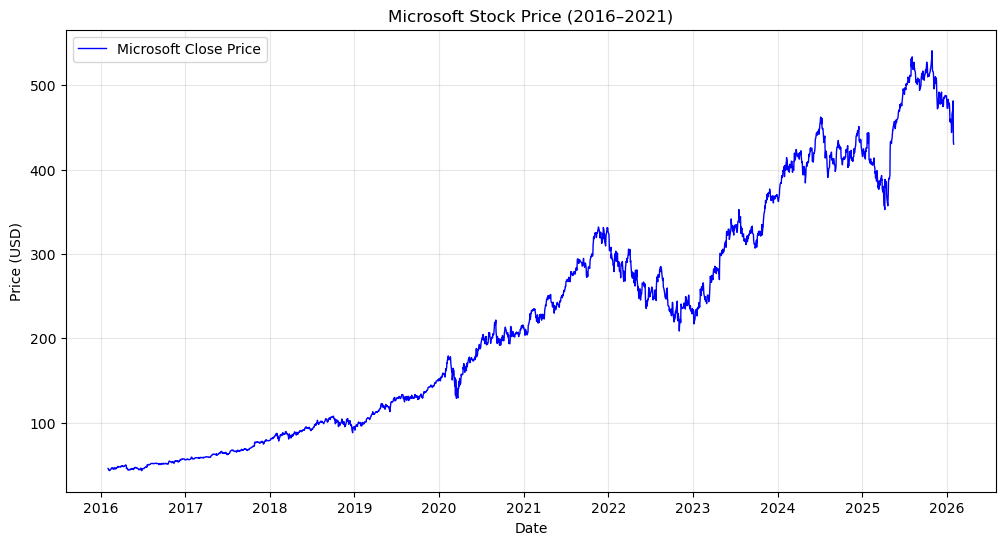

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Microsoft Close Price', color='blue', linewidth=1)
plt.title('Microsoft Stock Price (2016–2021)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Data info and Statistical summary

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2513 entries, 2016-02-03 to 2026-01-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2513 non-null   float64
 1   High    2513 non-null   float64
 2   Low     2513 non-null   float64
 3   Open    2513 non-null   float64
 4   Volume  2513 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.8 KB


In [7]:
df.describe()

,Close,High,Low,Open,Volume
count,2513.000000,2513.000000,2513.000000,2513.000000,2.513000e+03
mean,226.200643,228.252414,223.944978,226.159672,2.737961e+07
std,140.579875,141.723563,139.352367,140.607698,1.236230e+07
min,43.009026,43.404025,42.195681,42.624725,5.855900e+06
25%,96.165787,97.073339,94.680738,95.913164,1.963780e+07
50%,218.692276,222.236544,215.682033,218.376077,2.425760e+07
75%,325.623138,328.851366,323.007518,325.781525,3.135600e+07
max,541.057373,553.502444,539.759814,553.283183,1.335030e+08


# Calculate daily returns (percentage change)

In [8]:
df['Daily_Return'] = df['Close'].pct_change() * 100
df[['Close', 'Daily_Return']].head()

,Close,Daily_Return
Date,,
2016-02-03,45.671837,NaN
2016-02-04,45.531754,-0.306717
2016-02-05,43.920628,-3.538467
2016-02-08,43.263927,-1.495198
2016-02-09,43.150074,-0.263160


# Plot daily returns over time

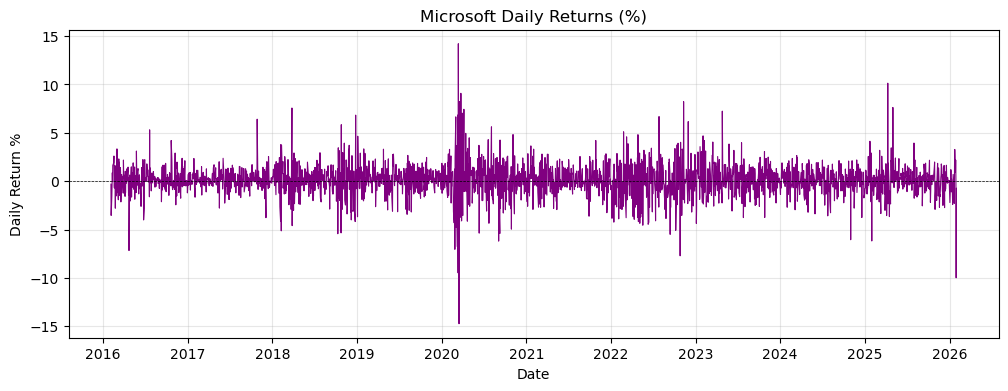

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(df['Daily_Return'], color='purple', linewidth=0.8)
plt.title('Microsoft Daily Returns (%)')
plt.xlabel('Date')
plt.ylabel('Daily Return %')
plt.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
plt.grid(True, alpha=0.3)
plt.show()

# Calculate and plot rolling volatility (30-day window)

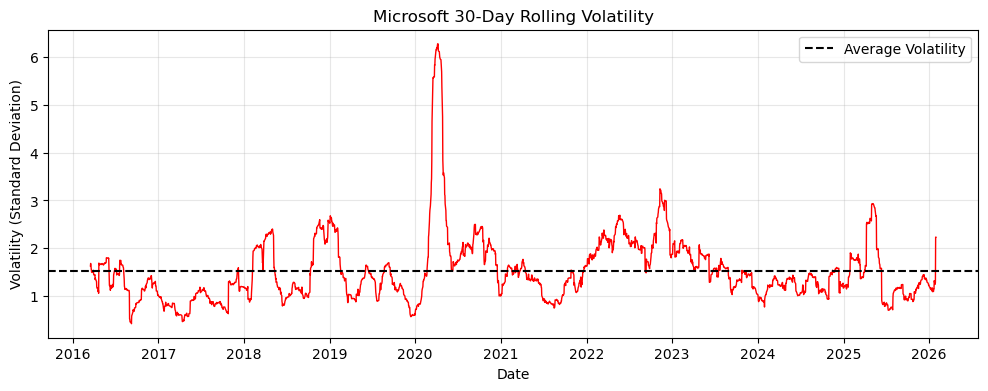

In [10]:
df['Rolling_Volatility'] = df['Daily_Return'].rolling(window=30).std()
plt.figure(figsize=(12, 4))
plt.plot(df['Rolling_Volatility'], color='red', linewidth=1)
plt.title('Microsoft 30-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility (Standard Deviation)')
plt.grid(True, alpha=0.3)
plt.axhline(y=df['Rolling_Volatility'].mean(), color='black', linestyle='--', label='Average Volatility')
plt.legend()
plt.show()

In [11]:
clean_returns = df['Daily_Return'].dropna().values
N = len(clean_returns)
fs = 1  # per day

In [12]:
clean_returns

array([-0.30671706, -3.53846672, -1.49519752, ...,  0.21848981,
       -9.99314918, -0.74048246])

In [13]:
df.head()

,Close,High,Low,Open,Volume,Daily_Return,Rolling_Volatility
Date,,,,,,,
2016-02-03,45.671837,46.748837,44.883786,46.626252,57559800,NaN,NaN
2016-02-04,45.531754,46.240999,44.980118,45.619313,46987100,-0.306717,NaN
2016-02-05,43.920628,45.531751,43.395263,45.479213,62009000,-3.538467,NaN
2016-02-08,43.263927,43.404025,42.195681,43.386512,59290500,-1.495198,NaN
2016-02-09,43.150074,43.990662,42.615951,42.922417,46740500,-0.263160,NaN


# Perform the FFT

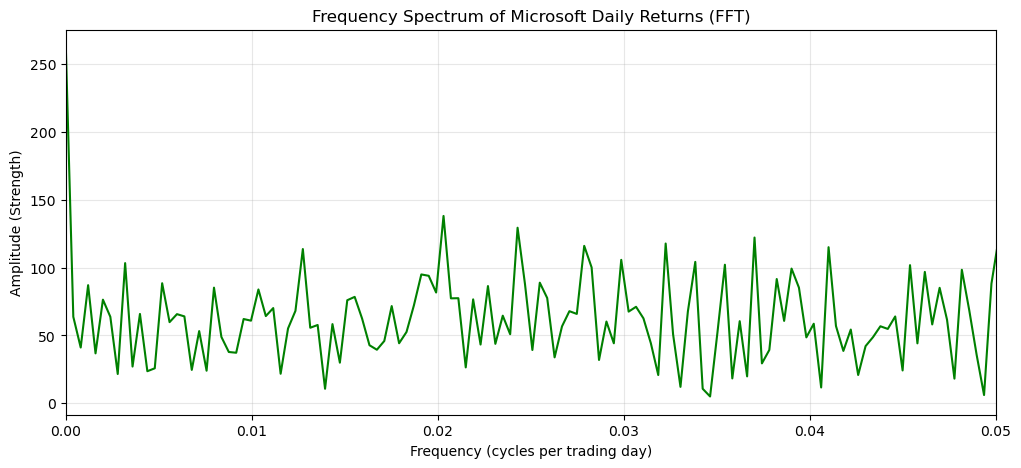

In [16]:
fft_result = np.fft.fft(clean_returns)

freqs = np.fft.fftfreq(N, d=1/fs)

positive_freqs = freqs[:N//2]
positive_fft = np.abs(fft_result[:N//2])

plt.figure(figsize=(12, 5))
plt.plot(positive_freqs, positive_fft, color='green')
plt.title('Frequency Spectrum of Microsoft Daily Returns (FFT)')
plt.xlabel('Frequency (cycles per trading day)')
plt.ylabel('Amplitude (Strength)')
plt.grid(True, alpha=0.3)
plt.xlim(0, 0.05)  # Zoom into low frequencies (longer cycles)
plt.show()

# Identify dominant cycles (in days)

In [17]:
# Find the top 5 strongest frequencies (excluding near-zero frequency)
top_indices = np.argsort(positive_fft[1:])[-5:] + 1  # skip the first (0 frequency)
top_frequencies = positive_freqs[top_indices]
top_periods = 1 / top_frequencies  # Convert frequency to period in days

print("Top 5 dominant cycles (in trading days):")
for period in top_periods:
    print(f"  ~{period:.1f} days")

Top 5 dominant cycles (in trading days):
  ~2.3 days
  ~2.3 days
  ~2.3 days
  ~2.2 days
  ~2.3 days


In [18]:
# Convert trading days to approximate calendar time
# (252 trading days ≈ 1 year, 21 trading days ≈ 1 month)
trading_days_per_year = 252
trading_days_per_month = 21

print("Dominant cycles in more familiar terms:\n")
for period in top_periods:
    years = period / trading_days_per_year
    months = period / trading_days_per_month
    print(f"~{period:.1f} trading days → about {months:.1f} months ({years:.2f} years)")

Dominant cycles in more familiar terms:

~2.3 trading days → about 0.1 months (0.01 years)
~2.3 trading days → about 0.1 months (0.01 years)
~2.3 trading days → about 0.1 months (0.01 years)
~2.2 trading days → about 0.1 months (0.01 years)
~2.3 trading days → about 0.1 months (0.01 years)


# Visualize the strongest cycle on the price chart

Strongest cycle: 2.3 trading days


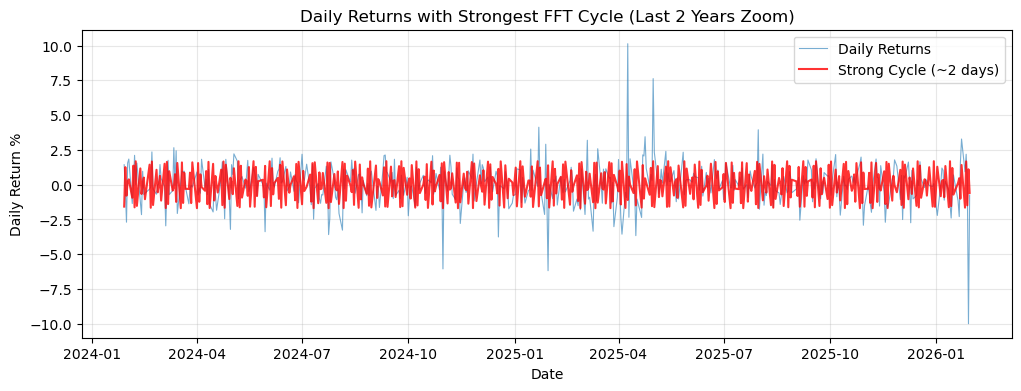

In [19]:
# Find the strongest non-zero frequency
strongest_idx = np.argmax(positive_fft[1:]) + 1
strong_freq = positive_freqs[strongest_idx]
strong_period = 1 / strong_freq

print(f"Strongest cycle: {strong_period:.1f} trading days")

# Create a synthetic sine wave at that frequency
t = np.arange(len(clean_returns))
sine_wave = np.sin(2 * np.pi * strong_freq * t) * np.std(clean_returns)

# Zoom into last 2 years of data for visibility
zoom_days = 504  # ~2 years of trading days
plt.figure(figsize=(12, 4))
plt.plot(df.index[-zoom_days:], clean_returns[-zoom_days:], alpha=0.6, label='Daily Returns', linewidth=0.8)
plt.plot(df.index[-zoom_days:], sine_wave[-zoom_days:], color='red', alpha=0.8, label=f'Strong Cycle (~{strong_period:.0f} days)')
plt.title('Daily Returns with Strongest FFT Cycle (Last 2 Years Zoom)')
plt.xlabel('Date')
plt.ylabel('Daily Return %')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Detect volatility clusters visually

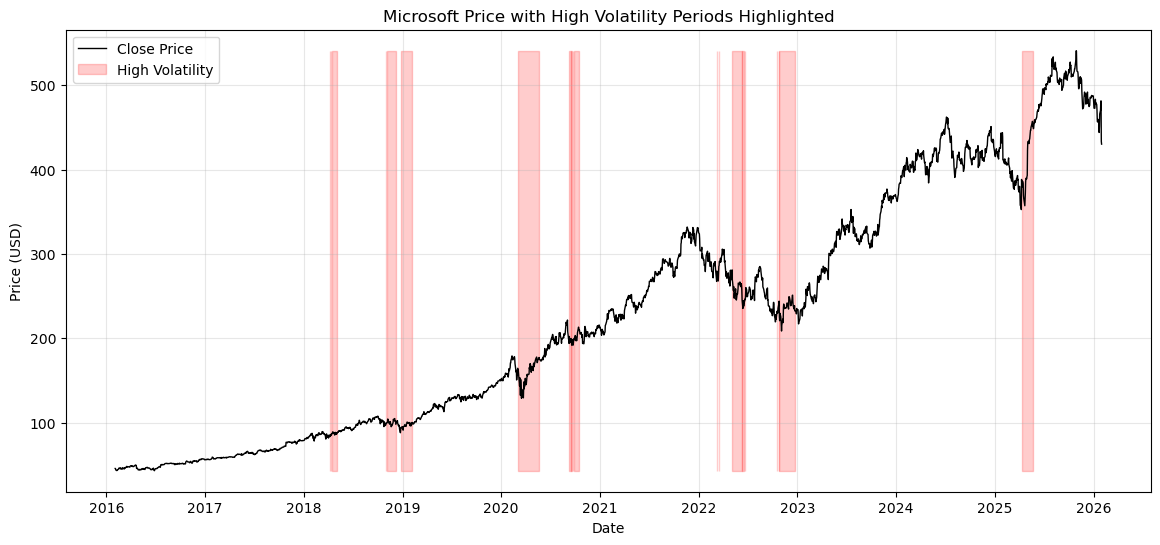

In [20]:
# Define "high volatility" as > 1.5 times the average
vol_threshold = df['Rolling_Volatility'].mean() * 1.5
high_vol_periods = df['Rolling_Volatility'] > vol_threshold

# Plot closing price with high-vol periods shaded
plt.figure(figsize=(14, 6))
plt.plot(df['Close'], label='Close Price', color='black', linewidth=1)
plt.fill_between(df.index, df['Close'].min(), df['Close'].max(),
                 where=high_vol_periods, color='red', alpha=0.2, label='High Volatility')
plt.title('Microsoft Price with High Volatility Periods Highlighted')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Prepare features for clustering

In [21]:
# Create features
df['Rolling_Avg_Return'] = df['Daily_Return'].rolling(window=30).mean()

# Drop NaN rows (from rolling windows)
df_features = df[['Daily_Return', 'Rolling_Volatility', 'Rolling_Avg_Return']].dropna()
df_features.head()

,Daily_Return,Rolling_Volatility,Rolling_Avg_Return
Date,,,
2016-03-17,0.570377,1.626727,0.192869
2016-03-18,-2.140509,1.679737,0.131742
2016-03-21,0.691709,1.532078,0.272748
2016-03-22,0.389902,1.495283,0.335585
2016-03-23,-0.184966,1.494271,0.338191


# Scale the features

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_features)

# Show first few scaled rows
scaled_features[:5]

array([[ 0.2767523 ,  0.13671279,  0.37109773],
       [-1.32748652,  0.20946767,  0.10288808],
       [ 0.34855399,  0.00680857,  0.7215917 ],
       [ 0.16995196, -0.04369183,  0.99730559],
       [-0.17024182, -0.0450806 ,  1.00874222]])

# Apply K-Means clustering

In [24]:
from sklearn.cluster import KMeans

# Choose 4 clusters (calm, bullish, volatile, bearish)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_features)

# Add cluster labels back to DataFrame
df_features['Cluster'] = clusters

# See distribution
df_features['Cluster'].value_counts().sort_index()

Cluster
0    1369
1      30
2     610
3     474
Name: count, dtype: int64

# Visualize the clusters in 2D

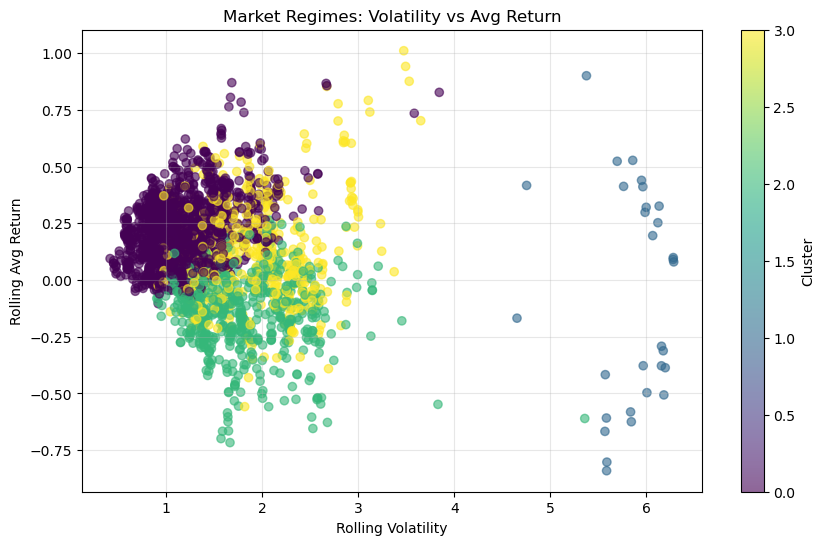

In [25]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_features['Rolling_Volatility'],
                      df_features['Rolling_Avg_Return'],
                      c=df_features['Cluster'],
                      cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.title('Market Regimes: Volatility vs Avg Return')
plt.xlabel('Rolling Volatility')
plt.ylabel('Rolling Avg Return')
plt.grid(alpha=0.3)
plt.show()

# Map clusters to readable labels

In [26]:
# Calculate mean values per cluster
cluster_summary = df_features.groupby('Cluster').mean()
print(cluster_summary)

# Assign intuitive labels
labels = {
    0: 'Calm',
    1: 'Bullish',
    2: 'Volatile',
    3: 'Bearish'
}

df_features['Regime'] = df_features['Cluster'].map(labels)
df_features['Regime'].value_counts()

         Daily_Return  Rolling_Volatility  Rolling_Avg_Return
Cluster                                                      
0            0.022736            1.178597            0.215030
1            1.381978            5.851434           -0.072267
2           -1.242578            1.787941           -0.134957
3            1.984016            1.924357            0.124489


Regime
Calm        1369
Volatile     610
Bearish      474
Bullish       30
Name: count, dtype: int64

# Plot regimes over time

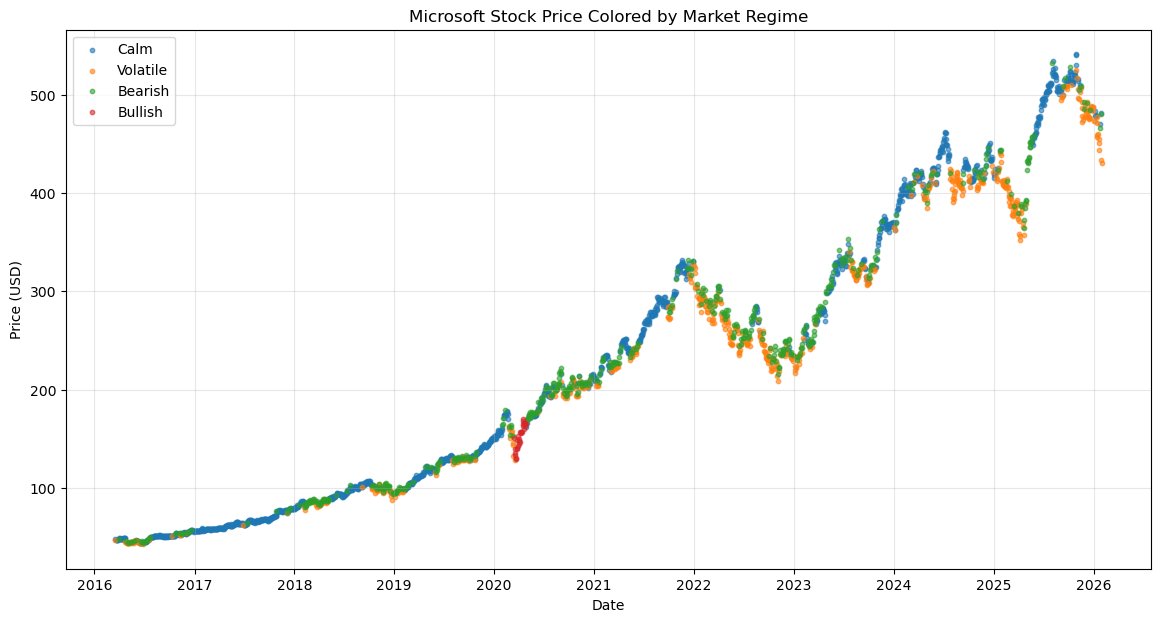

In [27]:
# Align regime labels with original date index
df_regimes = df.copy()
df_regimes['Regime'] = df_features['Regime']

# Plot price colored by regime
plt.figure(figsize=(14, 7))
for regime in df_regimes['Regime'].dropna().unique():
    regime_data = df_regimes[df_regimes['Regime'] == regime]
    plt.scatter(regime_data.index, regime_data['Close'],
                label=regime, alpha=0.6, s=10)

plt.title('Microsoft Stock Price Colored by Market Regime')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Day-of-week seasonality

Average Daily Return by Weekday:
Mon    0.071
Tue    0.084
Wed    0.208
Thu    0.051
Fri    0.101
Name: Daily_Return, dtype: float64


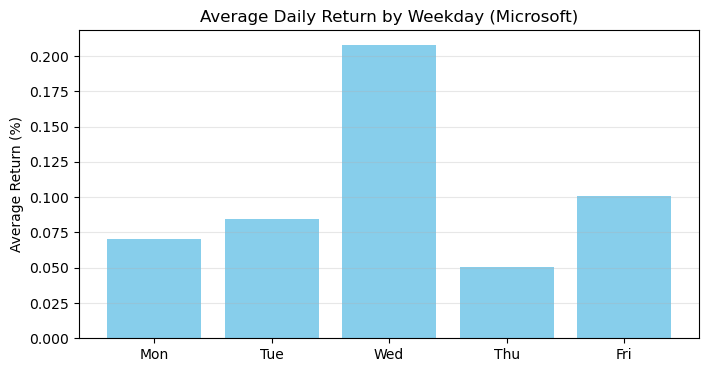

In [28]:
# Extract day of week (0=Monday, 4=Friday)
df['DayOfWeek'] = df.index.dayofweek

# Group by day of week and average the daily return
weekday_returns = df.groupby('DayOfWeek')['Daily_Return'].mean()

# Name the days
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
weekday_returns.index = days

print("Average Daily Return by Weekday:")
print(weekday_returns.round(3))

# Plot
plt.figure(figsize=(8, 4))
bars = plt.bar(weekday_returns.index, weekday_returns.values, color='skyblue')
# Color negative bars red
for bar, val in zip(bars, weekday_returns.values):
    if val < 0:
        bar.set_color('coral')
plt.title('Average Daily Return by Weekday (Microsoft)')
plt.ylabel('Average Return (%)')
plt.axhline(y=0, color='black', linewidth=0.5)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Monthly seasonality heatmap

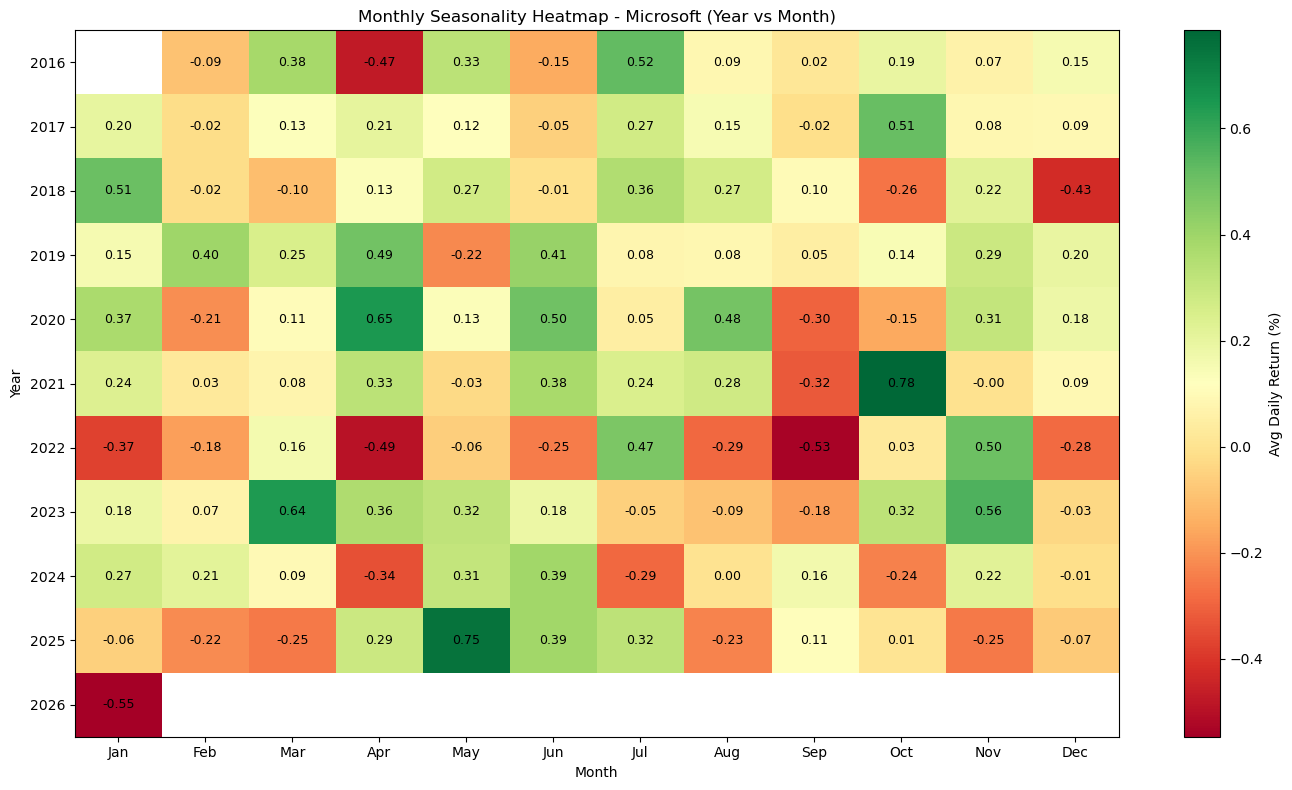

In [29]:
# Extract month and year
df['Month'] = df.index.month
df['Year'] = df.index.year

# Pivot table: average daily return per month per year
monthly_pivot = df.pivot_table(values='Daily_Return', index='Year', columns='Month', aggfunc='mean')

# Plot heatmap with values
plt.figure(figsize=(14, 8))
im = plt.imshow(monthly_pivot, cmap='RdYlGn', aspect='auto', interpolation='nearest')
plt.colorbar(im, label='Avg Daily Return (%)')
plt.title('Monthly Seasonality Heatmap - Microsoft (Year vs Month)')
plt.xlabel('Month')
plt.ylabel('Year')

# Set ticks
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(range(12), month_names)
plt.yticks(range(len(monthly_pivot)), monthly_pivot.index)

# Add text annotations in each cell
for i in range(len(monthly_pivot)):  # rows (years)
    for j in range(12):  # columns (months)
        value = monthly_pivot.iloc[i, j]
        if not pd.isna(value):
            # Format to 2 decimal places
            text = f'{value:.2f}'
            # Choose text color based on background brightness
            color = 'black' if abs(value) < 1 else 'white'
            plt.text(j, i, text, ha='center', va='center', color=color, fontsize=9)

plt.tight_layout()
plt.show()

# Find top 10 craziest days

In [30]:
# Get absolute daily return
df['Abs_Return'] = df['Daily_Return'].abs()

# Top 10 biggest moves
top10_crazy = df.nlargest(10, 'Abs_Return')[['Close', 'Daily_Return']]
top10_crazy

,Close,Daily_Return
Date,,
2020-03-16,128.929962,-14.739030
2020-03-13,151.218033,14.216904
2025-04-09,388.407776,10.133695
2026-01-29,433.500000,-9.993149
2020-03-12,132.395493,-9.483849
2020-03-24,141.230774,9.089593
2020-03-17,139.545563,8.233618
2022-11-10,236.639389,8.226820
2022-10-26,225.283661,-7.715622


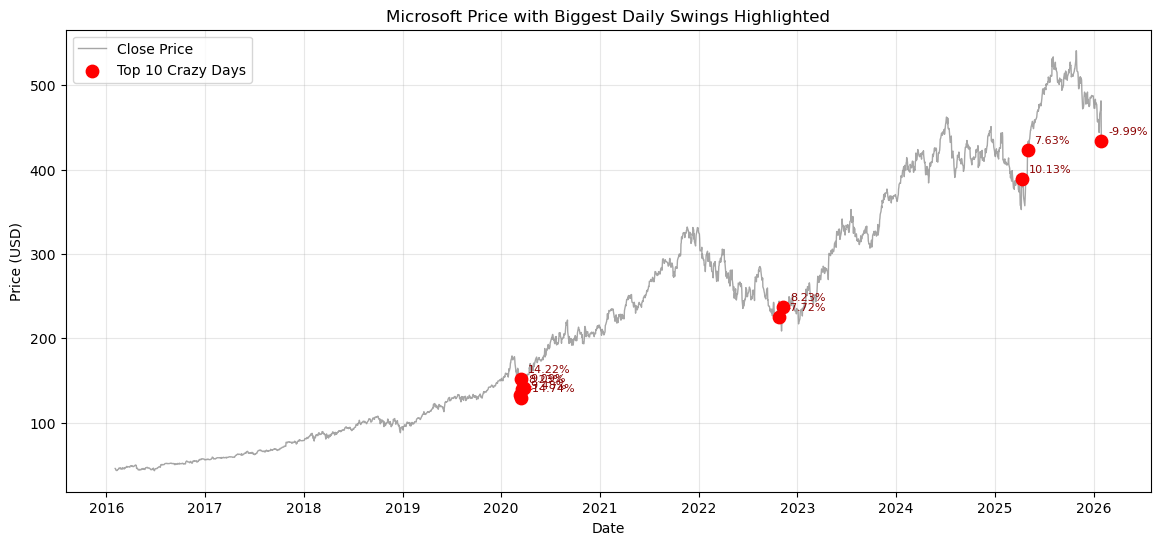

In [31]:
# Highlight top 10 crazy days on price chart
plt.figure(figsize=(14, 6))
plt.plot(df['Close'], color='gray', linewidth=1, alpha=0.7, label='Close Price')
plt.scatter(top10_crazy.index, df.loc[top10_crazy.index, 'Close'],
            color='red', s=80, zorder=5, label='Top 10 Crazy Days')
plt.title('Microsoft Price with Biggest Daily Swings Highlighted')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)

# Annotate each point with return %
for date, row in top10_crazy.iterrows():
    plt.annotate(f"{row['Daily_Return']:.2f}%",
                 xy=(date, df.loc[date, 'Close']),
                 xytext=(5, 5), textcoords='offset points',
                 fontsize=8, color='darkred')

plt.show()

# Final summary report

In [32]:
print("="*50)
print("MICROSOFT STOCK ANALYSIS SUMMARY (2016-2021)")
print("="*50)

# 1. Basic stats
print("\nBASIC STATS:")
print(f"   Start Date: {df.index[0].date()}")
print(f"   End Date:   {df.index[-1].date()}")
print(f"   Start Price: ${df['Close'].iloc[0]:.2f}")
print(f"   End Price:   ${df['Close'].iloc[-1]:.2f}")
print(f"   Total Return: {((df['Close'].iloc[-1] / df['Close'].iloc[0]) - 1) * 100:.2f}%")

# 2. Volatility
print("\nVOLATILITY:")
print(f"   Avg Daily Return: {df['Daily_Return'].mean():.3f}%")
print(f"   Avg Rolling Volatility: {df['Rolling_Volatility'].mean():.3f}")

# 3. Strongest cycle from earlier FFT
print("\nSTRONGEST HIDDEN CYCLE:")
print(f"   ~{strong_period:.1f} trading days ({strong_period/21:.1f} months)")

# 4. Regimes
print("\nMARKET REGIMES (from clustering):")
print(df_features['Regime'].value_counts().to_string())

# 5. Best/Worst Weekday
best_day = weekday_returns.idxmax()
worst_day = weekday_returns.idxmin()
print(f"\nBEST WEEKDAY: {best_day} ({weekday_returns[best_day]:.3f}%)")
print(f"WORST WEEKDAY: {worst_day} ({weekday_returns[worst_day]:.3f}%)")

# 6. Craziest day ever
craziest = df.loc[df['Abs_Return'].idxmax()]
print(f"\nCRAZIEST DAY: {craziest.name.date()}")
print(f"   Return: {craziest['Daily_Return']:.2f}%")
print(f"   Close: ${craziest['Close']:.2f}")

print("\n" + "="*50)
print("Analysis complete!")
print("="*50)

MICROSOFT STOCK ANALYSIS SUMMARY (2016-2021)

BASIC STATS:
   Start Date: 2016-02-03
   End Date:   2026-01-30
   Start Price: $45.67
   End Price:   $430.29
   Total Return: 842.13%

VOLATILITY:
   Avg Daily Return: 0.104%
   Avg Rolling Volatility: 1.527

STRONGEST HIDDEN CYCLE:
   ~2.3 trading days (0.1 months)

MARKET REGIMES (from clustering):
Regime
Calm        1369
Volatile     610
Bearish      474
Bullish       30

BEST WEEKDAY: Wed (0.208%)
WORST WEEKDAY: Thu (0.051%)

CRAZIEST DAY: 2020-03-16
   Return: -14.74%
   Close: $128.93

Analysis complete!
